In [23]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import numpy as np

In [24]:
def plot_boundary(ax, data, tgt, model, dims, grid_step = .01):
    twoD = data[:, list(dims)]
    min_x1, min_x2 = np.min(twoD, axis=0) + 2 * grid_step
    max_x1, max_x2 = np.max(twoD, axis=0) - grid_step
    xs, ys = np.mgrid[min_x1:max_x1:grid_step, min_x2:max_x2:grid_step]
    grid_points = np.c_[xs.ravel(), ys.ravel()]
    preds = model.fit(twoD, tgt).predict(grid_points).reshape(xs.shape)
    ax.pcolormesh(xs,ys,preds,cmap=plt.cm.coolwarm)
    ax.set_xlim(min_x1, max_x1)
    ax.set_ylim(min_x2, max_x2)

In [25]:
iris = load_iris()
X, y = iris.data, iris.target

logreg_class = {
    'LogReg(saga)': LogisticRegression(solver='saga', max_iter=1000),
    'LogReg(SGD)': SGDClassifier(loss='log_loss', max_iter=1000),
}

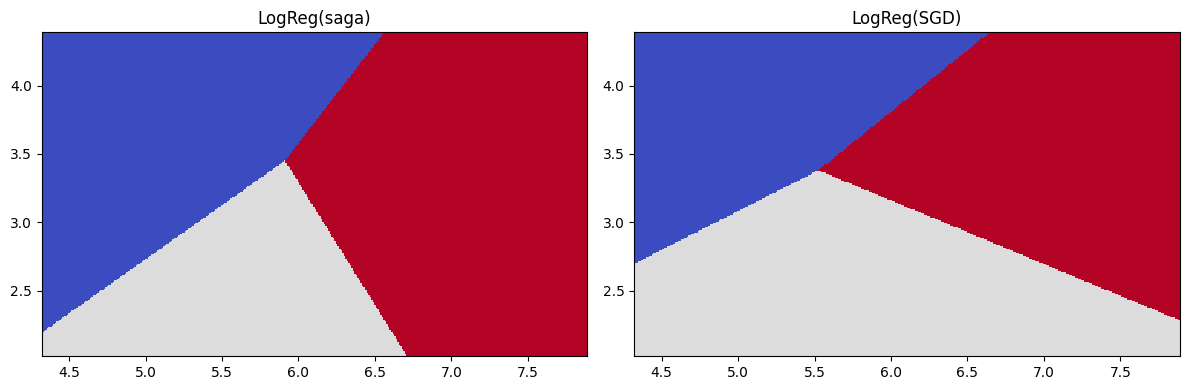

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (name, mod), ax in zip(logreg_class.items(), axes.flat):
    plot_boundary(ax, iris.data, iris.target, mod, [0, 1])
    ax.set_title(name)
plt.tight_layout()